# HW#2-7: Edge 검출 알고리즘 비교

Head CT 영상에 대해 4가지 Edge 검출 알고리즘을 적용하고 결과를 비교한다.
- Sobel
- Laplacian
- Canny
- Morphological Gradient

Image shape: (512, 512), dtype: uint8


[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.150] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

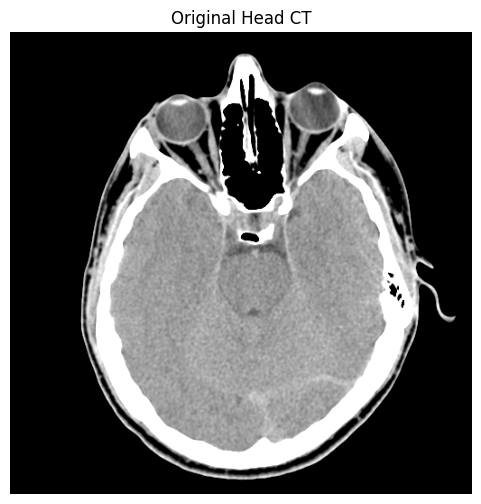

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 영상 로드
img = cv2.imread('data/Fig0939(a)(headCT-Vandy).tif', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Head CT')
plt.axis('off')
plt.show()

## 1. Sobel Edge Detection

1차 미분 기반. 수평/수직 gradient를 각각 구한 후 magnitude를 합성한다.  
노이즈에 비교적 강하고, 방향 정보를 제공한다.

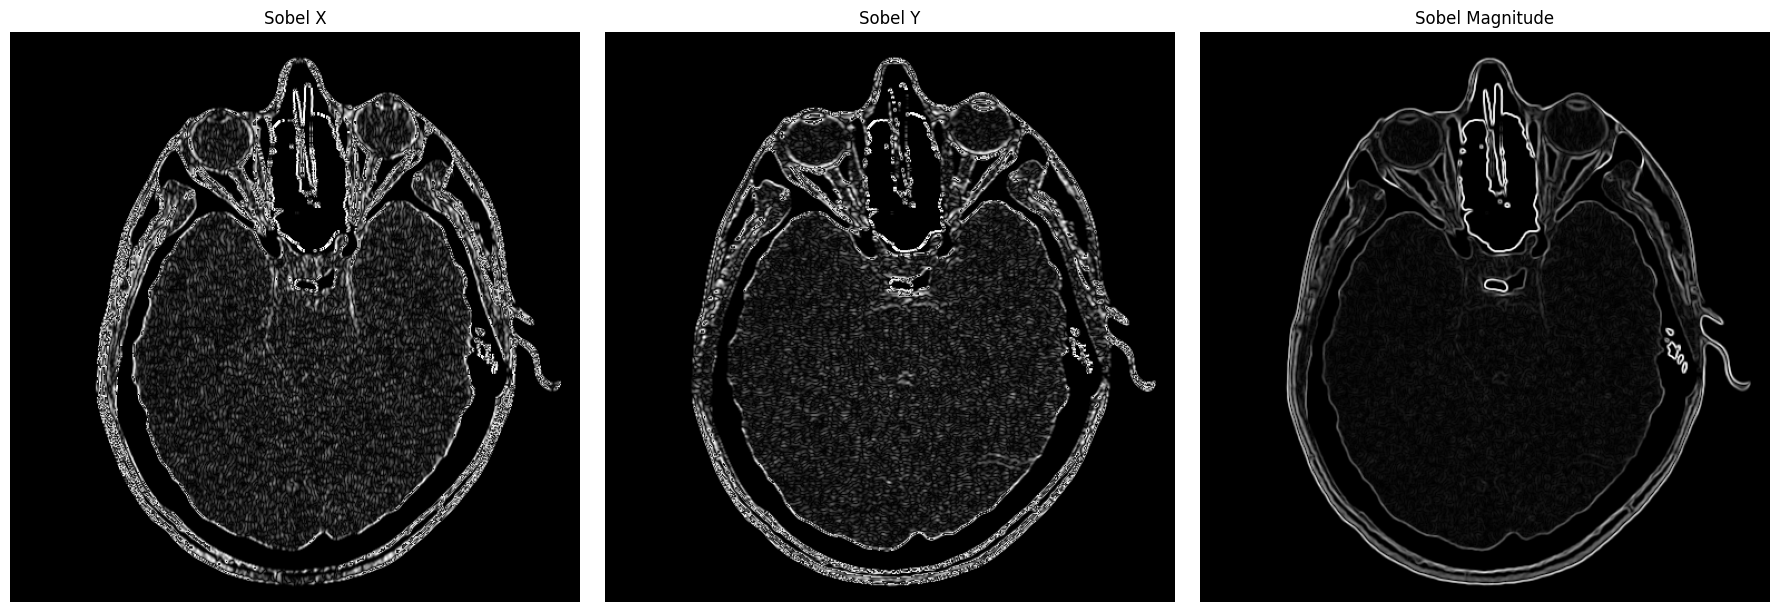

In [2]:
# Sobel
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag / sobel_mag.max() * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(np.abs(sobel_x).astype(np.uint8), cmap='gray')
axes[0].set_title('Sobel X')
axes[0].axis('off')

axes[1].imshow(np.abs(sobel_y).astype(np.uint8), cmap='gray')
axes[1].set_title('Sobel Y')
axes[1].axis('off')

axes[2].imshow(sobel_mag, cmap='gray')
axes[2].set_title('Sobel Magnitude')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 2. Laplacian Edge Detection

2차 미분 기반. 방향에 무관하게 edge를 검출하지만 노이즈에 민감하다.  
zero-crossing 지점이 edge가 된다.

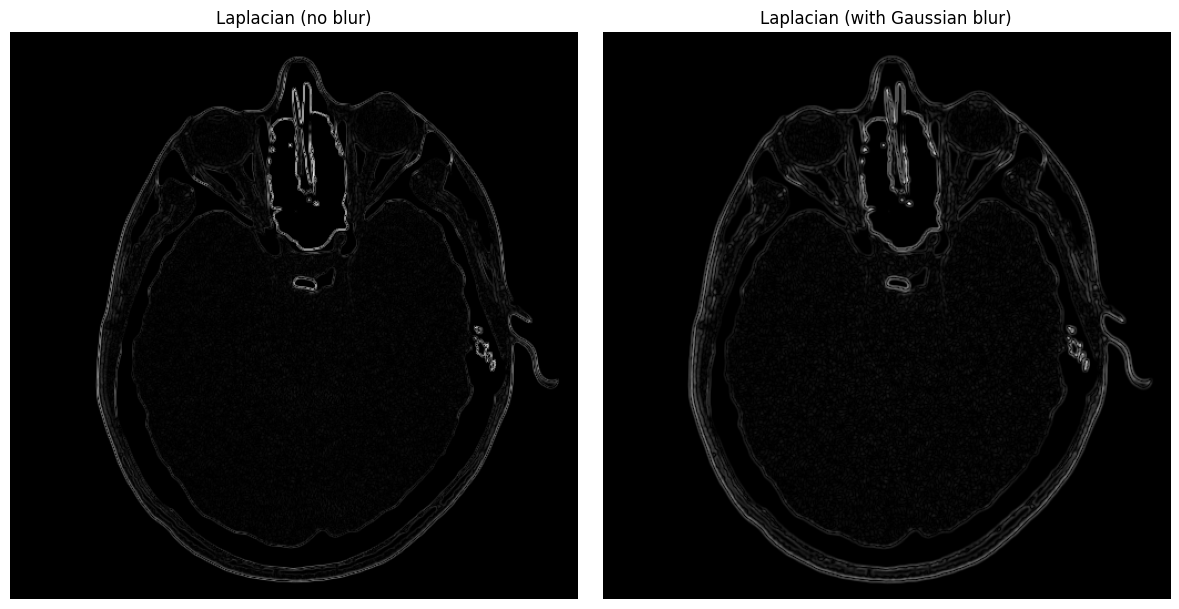

In [3]:
# Laplacian
# 노이즈 민감하므로 Gaussian blur 선행
img_blur = cv2.GaussianBlur(img, (3, 3), 0)

lap = cv2.Laplacian(img_blur, cv2.CV_64F, ksize=3)
lap_abs = np.abs(lap)
lap_vis = np.clip(lap_abs / lap_abs.max() * 255, 0, 255).astype(np.uint8)

# blur 없이도 비교
lap_raw = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
lap_raw_vis = np.clip(np.abs(lap_raw) / np.abs(lap_raw).max() * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(lap_raw_vis, cmap='gray')
axes[0].set_title('Laplacian (no blur)')
axes[0].axis('off')

axes[1].imshow(lap_vis, cmap='gray')
axes[1].set_title('Laplacian (with Gaussian blur)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Canny Edge Detection

Gaussian smoothing → Gradient 계산 → Non-maximum suppression → Hysteresis thresholding  
얇고 연결된 edge를 생성하며, 가장 널리 사용되는 edge 검출기이다.

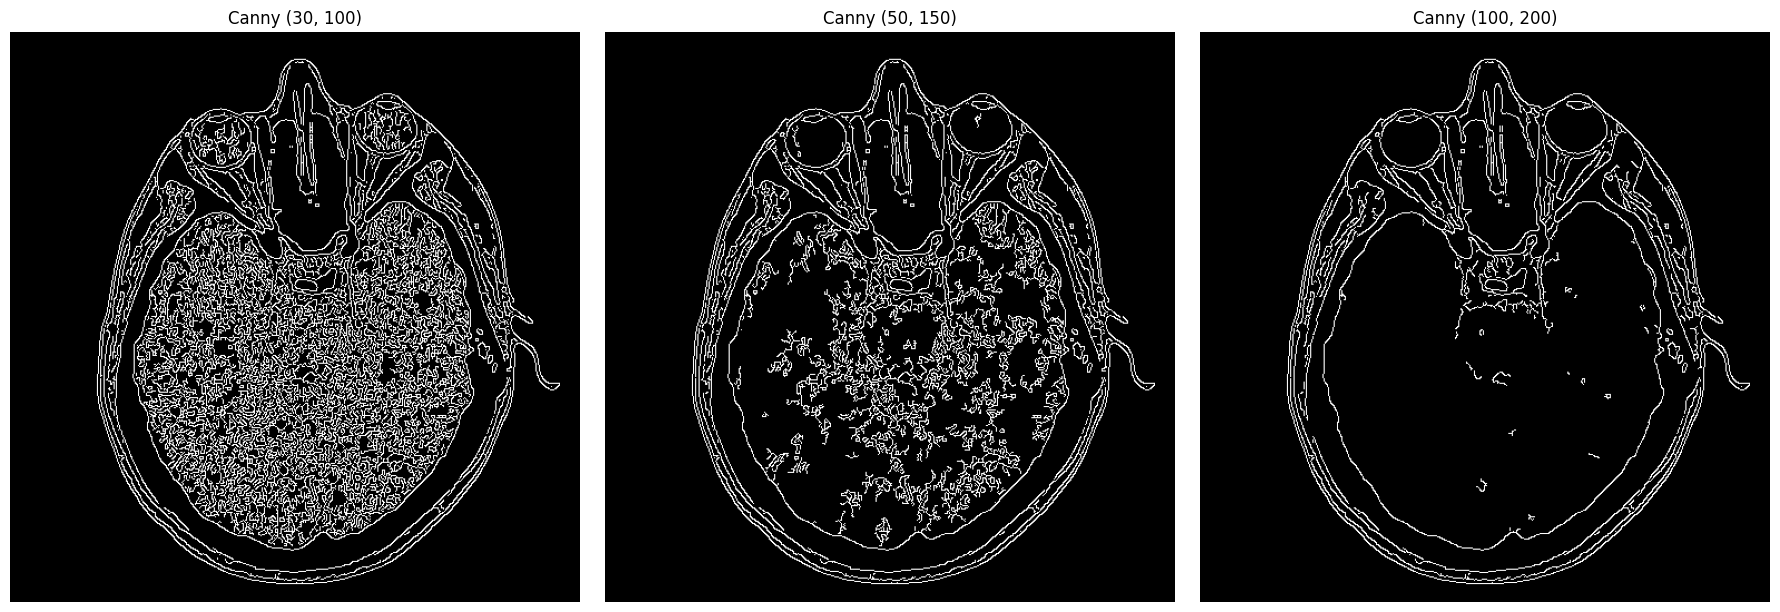

In [4]:
# Canny (다양한 threshold 비교)
canny_1 = cv2.Canny(img, 50, 150)
canny_2 = cv2.Canny(img, 100, 200)
canny_3 = cv2.Canny(img, 30, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(canny_3, cmap='gray')
axes[0].set_title('Canny (30, 100)')
axes[0].axis('off')

axes[1].imshow(canny_1, cmap='gray')
axes[1].set_title('Canny (50, 150)')
axes[1].axis('off')

axes[2].imshow(canny_2, cmap='gray')
axes[2].set_title('Canny (100, 200)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Morphological Gradient

Dilation - Erosion으로 edge를 검출한다.  
두꺼운 edge를 생성하며, 노이즈에 비교적 강하다.

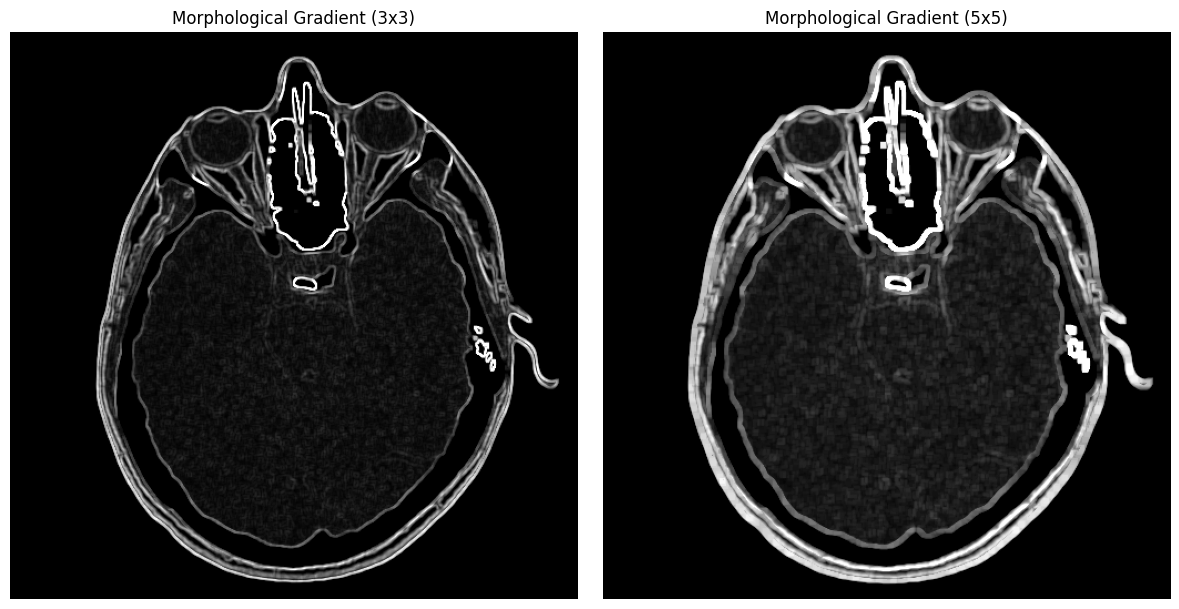

In [5]:
# Morphological Gradient
kernel_3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
kernel_5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

morph_grad_3 = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel_3)
morph_grad_5 = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel_5)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(morph_grad_3, cmap='gray')
axes[0].set_title('Morphological Gradient (3x3)')
axes[0].axis('off')

axes[1].imshow(morph_grad_5, cmap='gray')
axes[1].set_title('Morphological Gradient (5x5)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 전체 비교

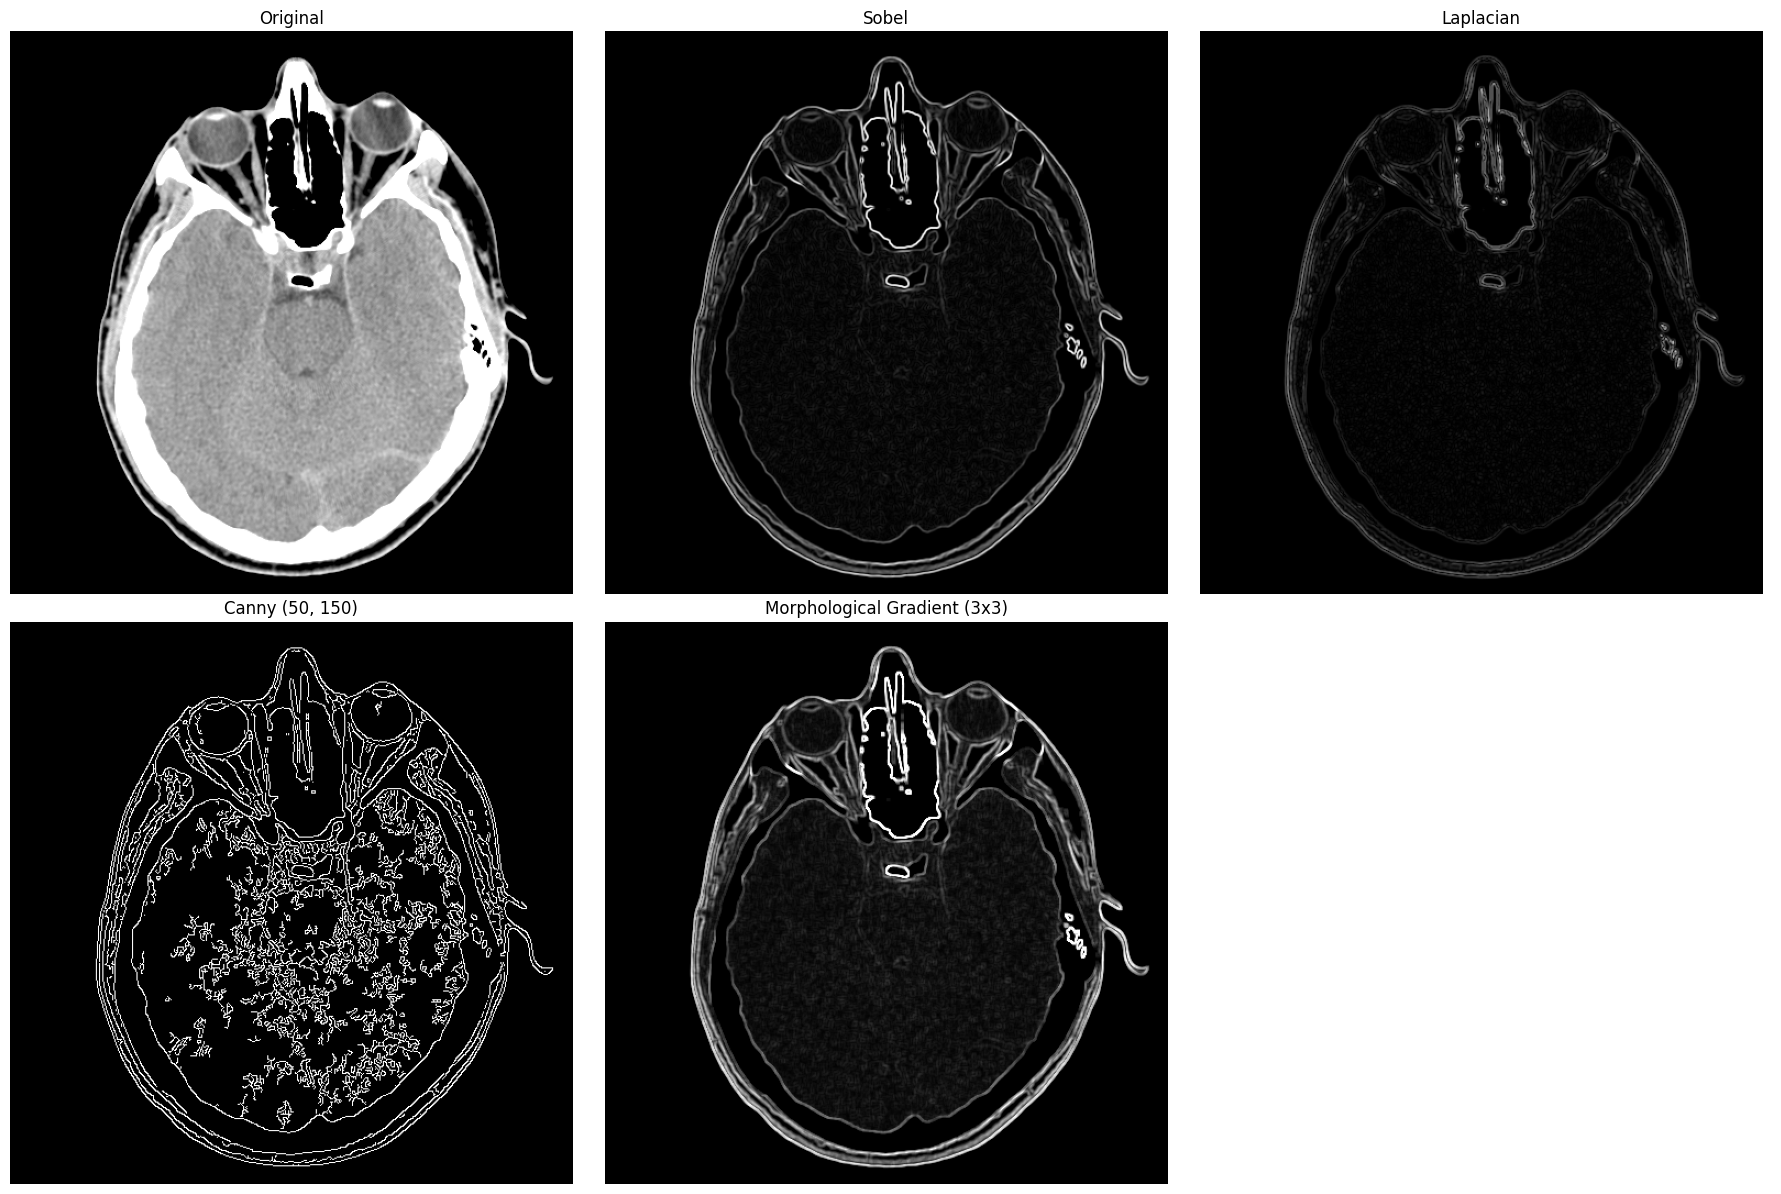

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel_mag, cmap='gray')
axes[0, 1].set_title('Sobel')
axes[0, 1].axis('off')

axes[0, 2].imshow(lap_vis, cmap='gray')
axes[0, 2].set_title('Laplacian')
axes[0, 2].axis('off')

axes[1, 0].imshow(canny_1, cmap='gray')
axes[1, 0].set_title('Canny (50, 150)')
axes[1, 0].axis('off')

axes[1, 1].imshow(morph_grad_3, cmap='gray')
axes[1, 1].set_title('Morphological Gradient (3x3)')
axes[1, 1].axis('off')

axes[1, 2].axis('off')  # 빈칸

plt.tight_layout()
plt.savefig('result/hw2_7_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 분석

| 알고리즘 | 미분 차수 | Edge 두께 | 노이즈 민감도 | 특징 |
|---------|---------|----------|------------|-----|
| Sobel | 1차 | 두꺼움 | 중간 | 방향별 gradient 제공, smoothing 내장 |
| Laplacian | 2차 | 중간 | 높음 | 방향 무관, 사전 blur 필요 |
| Canny | 1차+후처리 | 얇음(1px) | 낮음 | NMS+hysteresis로 깨끗한 edge, threshold 조절 중요 |
| Morph. Gradient | - | 두꺼움 | 낮음 | 단순하고 robust, SE 크기로 두께 조절 |

**Sobel:** CT 영상의 뼈/조직 경계가 넓은 band로 검출된다. 방향별 분석이 가능하지만 edge가 두껍다.

**Laplacian:** blur 없이 적용하면 노이즈가 심하게 증폭된다. Gaussian blur 후 적용하면 개선되지만 Sobel보다 노이즈에 민감하다.

**Canny:** 가장 깨끗하고 얇은 edge를 생성한다. threshold 값에 따라 검출되는 edge의 양이 크게 변한다. 낮은 threshold(30,100)는 세밀한 구조까지 검출하고, 높은 threshold(100,200)는 주요 경계만 검출한다.

**Morphological Gradient:** Dilation-Erosion으로 edge 폭이 SE 크기에 비례한다. 노이즈에 강하고 구현이 단순하지만, edge가 두꺼워 정밀한 위치 특정이 어렵다.